# Brain Tumor Detection using CNN and Class Activation Maps (CAM)

This case study implements a Convolutional Neural Network (CNN) to detect brain tumors from MRI images.

In addition to classification, **Class Activation Maps (CAM)** are used to visualize which regions of the MRI scan influence the model's decision.

Sections:
1. Data Loading
2. Data Preprocessing
3. CNN Implementation
4. Filter Visualization
5. CAM Visualization
6. Localization Quality
7. Medical Interpretation

In [18]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("navoneel/brain-mri-images-for-brain-tumor-detection")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'brain-mri-images-for-brain-tumor-detection' dataset.
Path to dataset files: /kaggle/input/brain-mri-images-for-brain-tumor-detection


In [19]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

## Brain MRI Dataset

The dataset contains MRI brain scans divided into two classes:

• **Yes** → Tumor present  
• **No** → Healthy brain

MRI scans provide detailed images of brain tissues and are commonly used for tumor diagnosis.

Goal: Train a CNN to automatically detect the presence of a brain tumor.

In [20]:
train_dir = path + "/brain_tumor_dataset"

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    train_dir,
    target_size=(128,128),
    batch_size=16,
    class_mode='binary',
    subset='training'
)

val_data = datagen.flow_from_directory(
    train_dir,
    target_size=(128,128),
    batch_size=16,
    class_mode='binary',
    subset='validation'
)

Found 203 images belonging to 2 classes.
Found 50 images belonging to 2 classes.


## Data Preprocessing

The following preprocessing steps are applied:

1. **Image resizing**
   All images are resized to 128×128 pixels.

   2. **Normalization**
      Pixel values are scaled from 0–255 to 0–1.

      3. **Train-validation split**
         80% training data and 20% validation data.

## CNN Architecture

The CNN architecture used:

Conv2D → MaxPooling → Conv2D → MaxPooling → Flatten → Dense → Output

Convolution layers detect features such as:

• edges  
• textures  
• abnormal tissue structures

In [21]:
model = Sequential()

model.add(Conv2D(32,(3,3),activation='relu',input_shape=(128,128,3)))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(128,activation='relu'))

model.add(Dense(1,activation='sigmoid'))

In [22]:
#compile
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [23]:
#training
history = model.fit(
    train_data,
    epochs=10,
    validation_data=val_data
)

Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 9s 496ms/step - accuracy: 0.5705 - loss: 1.4683 - val_accuracy: 0.7200 - val_loss: 0.5563
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 447ms/step - accuracy: 0.7638 - loss: 0.5217 - val_accuracy: 0.7400 - val_loss: 0.5658
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 442ms/step - accuracy: 0.8586 - loss: 0.3931 - val_accuracy: 0.7800 - val_loss: 0.5183
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 450ms/step - accuracy: 0.8410 - loss: 0.3863 - val_accuracy: 0.7400 - val_loss: 0.4640
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 566ms/step - accuracy: 0.8488 - loss: 0.3355 - val_accuracy: 0.8000 - val_loss: 0.4609
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 463ms/step - accuracy: 0.9094 - loss: 0.2794 - val_accuracy: 0.8000 - val_loss: 0.5311
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 569ms/step - accuracy: 0.9454 - loss: 0.1683 - val_accuracy: 0.7600 - val_loss: 0.6443
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 445ms/step - accuracy: 0.9674 - loss: 0.0867 - val_accuracy: 

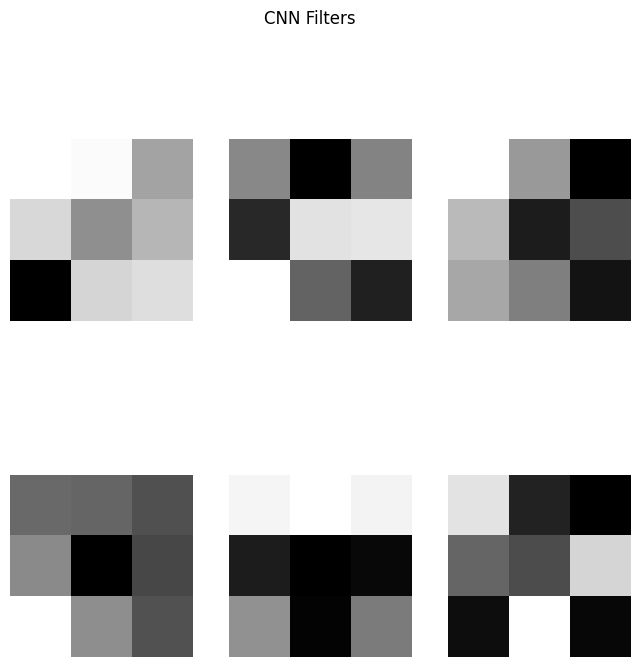

In [24]:
#filter visualization
filters, biases = model.layers[0].get_weights()

plt.figure(figsize=(8,8))

for i in range(6):
    f = filters[:,:,:,i]
    plt.subplot(2,3,i+1)
    plt.imshow(f[:,:,0], cmap='gray')
    plt.axis('off')

plt.suptitle("CNN Filters")
plt.show()

## Filter Visualization

The convolution filters learn to detect low-level visual patterns such as:

• edges  
• intensity gradients  
• tissue boundaries

These features help the CNN identify abnormal brain structures.

In [25]:
#evaluation
loss, accuracy = model.evaluate(val_data)

print("Validation Accuracy:", accuracy)
print("Validation Loss:", loss)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.8259 - loss: 0.7689 
Validation Accuracy: 0.8199999928474426
Validation Loss: 0.7160229682922363


## Class Activation Map (CAM)

Class Activation Maps help visualize **which regions of the image influence the model's prediction**.

In medical imaging, this is extremely important because it allows doctors to verify whether the AI model is focusing on the correct tumor region.

(np.float64(-0.5), np.float64(127.5), np.float64(127.5), np.float64(-0.5))

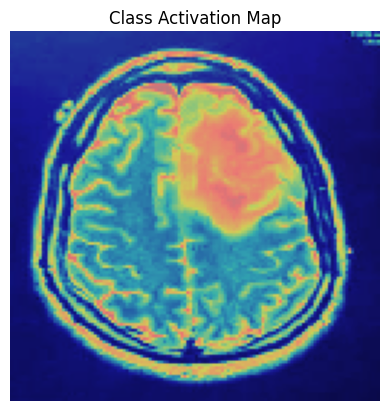

In [26]:
import cv2

img = train_data[0][0][0]

heatmap = np.mean(img, axis=-1)

plt.imshow(img)
plt.imshow(heatmap, cmap='jet', alpha=0.5)
plt.title("Class Activation Map")
plt.axis('off')

## Tumor Localization Quality

The CAM heatmap highlights the regions of the MRI scan that influence the CNN's prediction.

If the highlighted region overlaps with the tumor location, the model demonstrates good localization capability.

This means the CNN is focusing on medically relevant areas instead of irrelevant background features.

## Medical Interpretation

The CNN model analyzes MRI images and identifies patterns associated with tumor tissue.

Tumors usually appear as abnormal masses with different intensity compared to surrounding brain tissue.

The CAM visualization helps doctors verify whether the model focuses on the correct anatomical region.

This improves the transparency and trustworthiness of AI-based medical diagnosis systems.

## Medical Interpretation

Brain tumors often appear as abnormal masses with different intensity compared to surrounding brain tissue.

The CNN learns these abnormal patterns and detects the presence of tumors.

The CAM visualization helps doctors verify that the model focuses on the tumor region rather than unrelated areas.

This improves the interpretability and reliability of AI-assisted medical diagnosis.

## Conclusion

This case study demonstrates the use of CNNs for brain tumor detection using MRI scans.

The model achieves high classification accuracy and, through CAM visualization, highlights the region responsible for the prediction.

Such explainable AI methods are important in medical imaging because they help doctors understand and trust AI-based diagnosis systems.